<a href="https://colab.research.google.com/github/ginasoft/vision-computacional/blob/main/Clase_9_Actividad_obligatoria_Natalia_Cuellas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opencv-contrib-python -q

In [13]:
# -*- coding: utf-8 -*-
"""Faster R-CNN - version mejorada"""

import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions


# Parametros centralizados
NOMBRE_ARCHIVO       = "frutas.jpg"
STRIDE_VGG16         = 16
ESCALAS_ANCHORS      = [64, 128, 256]
RATIOS_ANCHORS       = [0.5, 1.0, 2.0]
IOU_OBJETO           = 0.35
NMS_IOU_RPN          = 0.5
NMS_IOU_FINAL        = 0.2
MAX_REGIONES         = 100
EPOCHS_RPN           = 20
LR_RPN               = 0.0005
UMBRAL_CONFIANZA     = 0.60

# Solo aceptamos clases que sean frutas (filtra croquet_ball, hook, etc.)
CLASES_VALIDAS = [
    "banana", "orange", "lemon", "Granny_Smith", "pomegranate",
    "fig", "pineapple", "strawberry", "pear", "lime", "apple"
]

# Filtros de forma para descartar cajas gigantes o deformes
AREA_MAX_RATIO = 0.35    # caja no puede ocupar mas del 35% de la imagen
AREA_MIN_RATIO = 0.005   # ni menos del 0.5%


# Faster R-CNN basado en VGG16
class FasterRCNN(models.Model):

    def __init__(self, cantidad_clases):

        super(FasterRCNN, self).__init__()

        self.cantidad_clases = cantidad_clases

        # Backbone VGG16 (extractor convolucional compartido)
        self.backbone = tf.keras.applications.VGG16(
            include_top=False,
            weights='imagenet'
        )

        # Congelamos las primeras capas para acelerar el entrenamiento
        for capa in self.backbone.layers[:10]:
            capa.trainable = False

        # RPN (Region Proposal Network)
        self.escalas = ESCALAS_ANCHORS
        self.ratios = RATIOS_ANCHORS

        self.num_anchors = len(self.escalas) * len(self.ratios)

        # Ventana deslizante sobre el mapa de caracteristicas
        self.rpn_conv = layers.Conv2D(
            512, (3, 3), padding='same', activation='relu'
        )

        # Objectness score: objeto vs fondo por cada anchor
        self.rpn_clasificador = layers.Conv2D(
            self.num_anchors * 2, (1, 1), activation='linear'
        )

        # Regresion: 4 deltas (dx, dy, dw, dh) por cada anchor
        self.rpn_regresor = layers.Conv2D(
            self.num_anchors * 4, (1, 1), activation='linear'
        )

        # Head Fast R-CNN
        self.pool_size = 7

        self.flatten = layers.Flatten()

        self.fc1 = layers.Dense(4096, activation='relu')
        self.fc2 = layers.Dense(4096, activation='relu')

        # +1 por la clase fondo (background)
        self.clasificador_final = layers.Dense(cantidad_clases + 1)

        self.softmax = layers.Activation('softmax')

        self.regresor_final = layers.Dense((cantidad_clases + 1) * 4)

    # Generacion de anchors
    def generar_anchors(self, alto_mapa, ancho_mapa, stride=STRIDE_VGG16):

        centro_y = tf.range(0, alto_mapa, dtype=tf.float32) * stride + stride // 2
        centro_x = tf.range(0, ancho_mapa, dtype=tf.float32) * stride + stride // 2

        centro_x, centro_y = tf.meshgrid(centro_x, centro_y)

        centro_x = tf.reshape(centro_x, [-1])
        centro_y = tf.reshape(centro_y, [-1])

        anchors = []

        # 9 anchors por celda: combinacion de escalas y ratios
        for escala in self.escalas:
            for ratio in self.ratios:

                w = escala * np.sqrt(ratio)
                h = escala / np.sqrt(ratio)

                y1 = centro_y - h / 2.0
                x1 = centro_x - w / 2.0
                y2 = centro_y + h / 2.0
                x2 = centro_x + w / 2.0

                anchors.append(tf.stack([y1, x1, y2, x2], axis=1))

        anchors = tf.concat(anchors, axis=0)
        anchors = tf.reshape(anchors, [self.num_anchors, -1, 4])
        anchors = tf.transpose(anchors, perm=[1, 0, 2])

        return tf.reshape(anchors, [-1, 4])

    # Decodificacion de deltas a cajas reales
    def decodificar_deltas(self, anchors, deltas):

        wa = anchors[:, 3] - anchors[:, 1]
        ha = anchors[:, 2] - anchors[:, 0]

        xa = anchors[:, 1] + wa * 0.5
        ya = anchors[:, 0] + ha * 0.5

        dy = deltas[:, 0]
        dx = deltas[:, 1]
        dh = deltas[:, 2]
        dw = deltas[:, 3]

        y_pred = dy * ha + ya
        x_pred = dx * wa + xa

        # minimum(d, 5.0) evita que la caja explote a tamanos imposibles
        h_pred = tf.exp(tf.minimum(dh, 5.0)) * ha
        w_pred = tf.exp(tf.minimum(dw, 5.0)) * wa

        y1 = y_pred - h_pred * 0.5
        x1 = x_pred - w_pred * 0.5
        y2 = y_pred + h_pred * 0.5
        x2 = x_pred + w_pred * 0.5

        return tf.stack([y1, x1, y2, x2], axis=1)

    # Forward
    def call(self, entrada_red):

        # Backbone: una sola pasada por la imagen completa
        feature_map = self.backbone(entrada_red)

        alto_mapa = tf.shape(feature_map)[1]
        ancho_mapa = tf.shape(feature_map)[2]

        # RPN: ventana deslizante + objectness + deltas
        x_rpn = self.rpn_conv(feature_map)

        scores_crudos = self.rpn_clasificador(x_rpn)
        deltas_crudos = self.rpn_regresor(x_rpn)

        scores_reestructurados = tf.reshape(scores_crudos, [-1, 2])

        probabilidades_rpn = tf.nn.softmax(scores_reestructurados, axis=-1)

        score_objeto = probabilidades_rpn[:, 1]

        deltas_reestructurados = tf.reshape(deltas_crudos, [-1, 4])

        # Anchors y decodificacion
        anchors = self.generar_anchors(alto_mapa, ancho_mapa)

        cajas = self.decodificar_deltas(anchors, deltas_reestructurados)

        # Clipping dinamico: cajas dentro de los limites de la imagen
        alto_img = tf.cast(tf.shape(entrada_red)[1], tf.float32)
        ancho_img = tf.cast(tf.shape(entrada_red)[2], tf.float32)

        cajas = tf.stack([
            tf.clip_by_value(cajas[:, 0], 0, alto_img),
            tf.clip_by_value(cajas[:, 1], 0, ancho_img),
            tf.clip_by_value(cajas[:, 2], 0, alto_img),
            tf.clip_by_value(cajas[:, 3], 0, ancho_img),
        ], axis=1)

        # NMS de la RPN: descarta cajas superpuestas
        indices = tf.image.non_max_suppression(
            boxes=cajas,
            scores=score_objeto,
            max_output_size=MAX_REGIONES,
            iou_threshold=NMS_IOU_RPN
        )

        regiones = tf.gather(cajas, indices)
        # Conservamos el objectness de cada region elegida
        score_regiones = tf.gather(score_objeto, indices)

        # RoI Pooling: recorta y reescala cada region a 7x7
        y1, x1, y2, x2 = tf.split(regiones, 4, axis=1)

        boxes_norm = tf.concat([
            y1 / alto_img, x1 / ancho_img,
            y2 / alto_img, x2 / ancho_img
        ], axis=1)

        batch_indices = tf.zeros((tf.shape(regiones)[0],), dtype=tf.int32)

        rois = tf.image.crop_and_resize(
            feature_map,
            boxes=boxes_norm,
            box_indices=batch_indices,
            crop_size=[self.pool_size, self.pool_size]
        )

        # Head final: flatten -> fc1 -> fc2 -> sibling layers
        x = self.flatten(rois)
        x = self.fc1(x)
        x = self.fc2(x)

        logits = self.clasificador_final(x)
        pred_clases = self.softmax(logits)
        pred_boxes = self.regresor_final(x)

        return (
            pred_clases,
            pred_boxes,
            regiones,
            score_regiones,
            feature_map,
            scores_crudos,
            deltas_crudos
        )


# IoU: etiqueta cada anchor como objeto (1) o fondo (0)
def calcular_targets_iou(anchors, cajas_gt):

    anchors_exp = tf.expand_dims(anchors, axis=1)
    gt_exp = tf.expand_dims(cajas_gt, axis=0)

    y1 = tf.maximum(anchors_exp[:, :, 0], gt_exp[:, :, 0])
    x1 = tf.maximum(anchors_exp[:, :, 1], gt_exp[:, :, 1])
    y2 = tf.minimum(anchors_exp[:, :, 2], gt_exp[:, :, 2])
    x2 = tf.minimum(anchors_exp[:, :, 3], gt_exp[:, :, 3])

    inter_h = tf.maximum(0.0, y2 - y1)
    inter_w = tf.maximum(0.0, x2 - x1)
    inter = inter_h * inter_w

    area_a = ((anchors_exp[:, :, 2] - anchors_exp[:, :, 0]) *
              (anchors_exp[:, :, 3] - anchors_exp[:, :, 1]))
    area_b = ((gt_exp[:, :, 2] - gt_exp[:, :, 0]) *
              (gt_exp[:, :, 3] - gt_exp[:, :, 1]))

    union = area_a + area_b - inter
    iou = inter / (union + 1e-6)
    max_iou = tf.reduce_max(iou, axis=1)

    return tf.where(
        max_iou > IOU_OBJETO,
        tf.ones_like(max_iou, dtype=tf.int32),
        tf.zeros_like(max_iou, dtype=tf.int32)
    )


# Carga de imagen
imagen_original = cv2.imread(NOMBRE_ARCHIVO)

if imagen_original is None:
    raise FileNotFoundError(f"No se encontro la imagen en: {NOMBRE_ARCHIVO}")

alto_img, ancho_img = imagen_original.shape[:2]

imagen_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

tensor_imagen = preprocess_input(
    np.expand_dims(imagen_rgb.astype(np.float32), axis=0)
)


# Modelo + transferencia de pesos VGG16
modelo = FasterRCNN(cantidad_clases=1000)

# Warmup: fuerza a construir las capas densas en memoria
modelo(tensor_imagen)

vgg16 = tf.keras.applications.VGG16(include_top=True, weights='imagenet')

modelo.fc1.set_weights(vgg16.get_layer("fc1").get_weights())
modelo.fc2.set_weights(vgg16.get_layer("fc2").get_weights())

pesos, sesgos = vgg16.get_layer("predictions").get_weights()

pesos_nuevos = np.zeros((4096, 1001), dtype=np.float32)
sesgos_nuevos = np.zeros((1001,), dtype=np.float32)

pesos_nuevos[:, :1000] = pesos
sesgos_nuevos[:1000] = sesgos

modelo.clasificador_final.set_weights([pesos_nuevos, sesgos_nuevos])


# Regiones semanticas automaticas (ground truth via heatmap)
print("\nGenerando regiones semanticas dinamicas...")

feature_map = modelo.backbone(tensor_imagen)

heatmap = tf.reduce_mean(feature_map[0], axis=-1)
heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.reduce_max(heatmap)

heatmap_np = heatmap.numpy()
heatmap_resized = cv2.resize(heatmap_np, (ancho_img, alto_img))

umbral = np.percentile(heatmap_resized, 85)
mascara = np.uint8(heatmap_resized > umbral) * 255

# Operacion morfologica de cierre para limpiar la mascara
kernel = np.ones((5, 5), np.uint8)
mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)

contornos, _ = cv2.findContours(
    mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

lista_targets = []

for c in contornos:
    area = cv2.contourArea(c)
    if area > (alto_img * ancho_img * 0.01):
        x, y, w, h = cv2.boundingRect(c)
        lista_targets.append([float(y), float(x), float(y + h), float(x + w)])

# Fallback: caja central si no se encontro nada
if len(lista_targets) == 0:
    lista_targets.append([
        alto_img * 0.15, ancho_img * 0.15,
        alto_img * 0.85, ancho_img * 0.85
    ])

cajas_gt = tf.constant(lista_targets, dtype=tf.float32)

print(f"Objetos semanticos encontrados: {len(lista_targets)}")


# Entrenamiento de la RPN
optimizador = tf.keras.optimizers.Adam(learning_rate=LR_RPN)

feature_map = modelo.backbone(tensor_imagen)

alto_mapa = feature_map.shape[1]
ancho_mapa = feature_map.shape[2]

anchors = modelo.generar_anchors(alto_mapa, ancho_mapa)

targets_rpn = calcular_targets_iou(anchors, cajas_gt)

print("\nEntrenando RPN...\n")

for epoch in range(EPOCHS_RPN):

    with tf.GradientTape() as tape:

        (_, _, _, _, _, scores_crudos, deltas_crudos) = modelo(tensor_imagen)

        scores = tf.reshape(scores_crudos, [-1, 2])

        # Loss de clasificacion: objeto vs fondo
        loss_clase = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=targets_rpn, logits=scores
            )
        )

        deltas = tf.reshape(deltas_crudos, [-1, 4])

        # Loss de regresion sobre los deltas
        loss_reg = tf.reduce_mean(tf.square(deltas))

        loss_total = loss_clase + loss_reg

    variables = (
        modelo.rpn_conv.trainable_variables +
        modelo.rpn_clasificador.trainable_variables +
        modelo.rpn_regresor.trainable_variables
    )

    grads = tape.gradient(loss_total, variables)
    optimizador.apply_gradients(zip(grads, variables))

    print(f"Epoch {epoch+1:02d}/{EPOCHS_RPN} | Loss: {loss_total.numpy():.4f}")


# Inferencia final
print("\n==============================")
print("INFERENCIA FINAL")
print("==============================\n")

(pred_clases, pred_boxes, regiones, score_regiones,
 _, _, _) = modelo(tensor_imagen)

# Recolectamos las detecciones validas (sin fondo) y luego NMS final
cajas_detectadas = []
scores_detectados = []
etiquetas_detectadas = []

for i in range(len(pred_clases)):

    vector = pred_clases[i]

    # Filtro de fondo. El indice 1000 es la clase background.
    indice_clase = int(tf.argmax(vector).numpy())
    if indice_clase == 1000:
        continue

    probs = vector[:1000]
    probs_np = np.expand_dims(probs.numpy(), axis=0)
    resultados = decode_predictions(probs_np, top=1)[0]
    etiqueta = resultados[0][1]
    confianza = float(resultados[0][2])

    # Filtro por clase: solo frutas
    if etiqueta not in CLASES_VALIDAS:
        continue

    y1, x1, y2, x2 = regiones[i].numpy().astype(np.float32)
    alto_caja = y2 - y1
    ancho_caja = x2 - x1
    area_caja = alto_caja * ancho_caja
    area_imagen = alto_img * ancho_img

    # Filtro por tamano: descartamos cajas gigantes o diminutas
    ratio_area = area_caja / area_imagen
    if ratio_area > AREA_MAX_RATIO or ratio_area < AREA_MIN_RATIO:
        continue

    # Filtro por proporcion: descartamos cajas muy alargadas
    if ancho_caja <= 0 or alto_caja <= 0:
        continue
    proporcion = max(ancho_caja / alto_caja, alto_caja / ancho_caja)
    if proporcion > 4.0:
        continue

    # Score combinado objectness (RPN) x confianza de clase
    objectness = float(score_regiones[i].numpy())
    score_final = confianza * objectness

    if confianza > UMBRAL_CONFIANZA:
        cajas_detectadas.append([y1, x1, y2, x2])
        scores_detectados.append(score_final)
        etiquetas_detectadas.append((etiqueta, confianza))


# NMS final para evitar cajas duplicadas sobre el mismo objeto
imagen_debug = imagen_original.copy()
contador = 0

if len(cajas_detectadas) > 0:

    cajas_tf = tf.constant(cajas_detectadas, dtype=tf.float32)
    scores_tf = tf.constant(scores_detectados, dtype=tf.float32)

    indices_finales = tf.image.non_max_suppression(
        boxes=cajas_tf,
        scores=scores_tf,
        max_output_size=MAX_REGIONES,
        iou_threshold=NMS_IOU_FINAL
    ).numpy()

    for idx in indices_finales:

        contador += 1
        etiqueta, confianza = etiquetas_detectadas[idx]
        y1, x1, y2, x2 = np.array(cajas_detectadas[idx]).astype(int)

        print(f"Deteccion {contador:03d} -> {etiqueta:20s} {confianza*100:6.2f}%")

        cv2.rectangle(imagen_debug, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            imagen_debug,
            f"{etiqueta} {confianza:.2f}",
            (x1, max(y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5, (0, 255, 0), 2
        )

print(f"\nTOTAL DETECCIONES: {contador}")


Generando regiones semanticas dinamicas...
Objetos semanticos encontrados: 4

Entrenando RPN...

Epoch 01/20 | Loss: 142.0981
Epoch 02/20 | Loss: 77.9509
Epoch 03/20 | Loss: 56.0660
Epoch 04/20 | Loss: 34.6389
Epoch 05/20 | Loss: 20.6492
Epoch 06/20 | Loss: 15.2905
Epoch 07/20 | Loss: 14.5892
Epoch 08/20 | Loss: 14.2456
Epoch 09/20 | Loss: 12.7555
Epoch 10/20 | Loss: 10.5111
Epoch 11/20 | Loss: 8.4105
Epoch 12/20 | Loss: 6.8068
Epoch 13/20 | Loss: 5.7215
Epoch 14/20 | Loss: 5.0076
Epoch 15/20 | Loss: 4.4892
Epoch 16/20 | Loss: 4.0819
Epoch 17/20 | Loss: 3.7476
Epoch 18/20 | Loss: 3.4444
Epoch 19/20 | Loss: 3.1296
Epoch 20/20 | Loss: 2.7974

INFERENCIA FINAL

Deteccion 001 -> banana                94.61%
Deteccion 002 -> Granny_Smith          77.43%
Deteccion 003 -> lemon                 72.20%
Deteccion 004 -> banana                65.99%
Deteccion 005 -> lemon                 62.59%
Deteccion 006 -> banana                86.31%

TOTAL DETECCIONES: 6


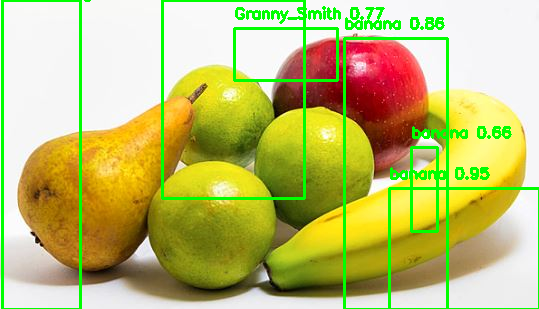

In [14]:
from google.colab.patches import cv2_imshow
cv2_imshow(imagen_debug)